![Logo](https://raw.githubusercontent.com/sadiam09/Beginner/main/logo.PNG)
# M32895 Big Data Applications (Main Coursework)
## UP2089630 Sadia Maio
## 2025/6
---

### Notebook Objectives
* Load and Validate the Bikesharing dataset from Kaggle (DONE)
* Perform Exploratory Data Analysis (EDA) to understand the data
* Build and train two ML models: Linear regression and Decision Tree Regressor
* Evaluate and compare model performance using R2, MAE, MSE and RMSE
* Predict bike rental demand on new data from input

### Inputs
* Dataset: `../datasets/hour.csv` downloaded from Kaggle using the Kaggle API

### Outputs
* Trained models saved in `../models/` folder

---
### <u>Data Collection</u>

In [1]:
"""
Download Bike Sharing Dataset
from Kaggle using the Kaggle API
"""
import kaggle

# Authenticate using Kaggle API token stored in ~/.kaggle/access_token
kaggle.api.authenticate()

# Download and unzip dataset into datasets folder
kaggle.api.dataset_download_files(
    'lakshmi25npathi/bike-sharing-dataset',
    path='../datasets/',
    unzip=True
)

print("Dataset downloaded successfully")

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset
Dataset downloaded successfully


---

### <u>Import Libraries</u>

In [2]:
"""
Import all required libraries
and modules for the ML pipeline
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import os

In [3]:
"""
Configure visualisation
for consistent plot styling
"""
sns.set_style('darkgrid')

---

### <u>Data Loading and Validation</u>

In [4]:
"""
Load the Bike Sharing dataset
from the datasets folder
"""
# load hourly bike sharing data
df = pd.read_csv('../datasets/hour.csv')

In [5]:
"""
Inspect the dataset
"""
# display first 5 rows
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [6]:
# display dataset info including column types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [7]:
# display a summary of the dataset
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [8]:
# check for missing values in each column
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [9]:
# drop rows with missing values (for presentation purposes as this datatset clearly has no missing values)
df = df.dropna()

# confirm no missing values remain
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

---

### <u>Exploratory Data Analysis (EDA)<u>

In [10]:
"""
Explore the dataset to understand
the structure and the contents within it
"""

# display first 5 rows again to display how the dataset looks currently
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [11]:
# display number of rows and columns (returned as a tuple)
df.shape

(17379, 17)

In [12]:
# display bike rental count distribution in a histogram
fig = px.histogram(
    df,  # datatset
    x='cnt',  # bike rental count on x axis
    marginal='box',
    title='Bike Rental Count Distribution'
)
fig.update_layout(bargap=0.1)  # add gaps between bars
fig.show()  # display chart

* Most bike rental counts are quite low, and only a smaller number of records have very high rental counts.
* This shows that the target column `cnt` is not evenly spread out. 
* It is useful to check this because `cnt` is the value the model is trying to predict.

In [13]:
# display distribution of temperature in a histogram
fig = px.histogram(
    df,
    x='temp',
    marginal='box',
    title='Temperature Distribution'
)
fig.update_layout(bargap=0.1)
fig.show()

* Most temperature values are in the middle of the range. 
* There are fewer records with very low or very high temperatures. 
* This is useful because temperature may affect how many people rent bikes.

In [ ]:
# display bike rentals by season in a bar chart
fig = px.histogram(
    df,
    x='season',
    color='season',  # colour bars by season
    title='Records by Season'
)
fig.show()

* The dataset has a similar number of records for each season. 
* This is good because the model has data from all seasons, instead of mostly learning from one season only.

In [15]:
# display bike rentals vs temperature on a scatter plot
fig = px.scatter(
    df,
    x='temp',  # temperature on x axis
    y='cnt',  # bike rentals on y axis
    color='season',
    opacity=0.8,  # point transparency
    title='Temperature vs Bike Rentals'
)
fig.update_traces(marker_size=5)  # point size
fig.show()

* The scatter plot shows that bike rentals increase when temperature increases. 
* However, the points are still spread out, so temperature is not the only thing affecting bike rentals. 
* Other features are also needed to help the model make better predictions.

In [16]:
# check correlation between features
df.select_dtypes(include='number').corr()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.000000,0.404046,0.866014,0.489164,-0.004775,0.014723,0.001357,-0.003416,-0.014198,0.136178,0.137615,0.009577,-0.074505,0.158295,0.282046,0.278379
season,0.404046,1.000000,-0.010742,0.830386,-0.006117,-0.009585,-0.002335,0.013743,-0.014524,0.312025,0.319380,0.150625,-0.149773,0.120206,0.174226,0.178056
yr,0.866014,-0.010742,1.000000,-0.010473,-0.003867,0.006692,-0.004485,-0.002196,-0.019157,0.040913,0.039222,-0.083546,-0.008740,0.142779,0.253684,0.250495
mnth,0.489164,0.830386,-0.010473,1.000000,-0.005772,0.018430,0.010400,-0.003477,0.005400,0.201691,0.208096,0.164411,-0.135386,0.068457,0.122273,0.120638
hr,-0.004775,-0.006117,-0.003867,-0.005772,1.000000,0.000479,-0.003498,0.002285,-0.020203,0.137603,0.133750,-0.276498,0.137252,0.301202,0.374141,0.394071
holiday,0.014723,-0.009585,0.006692,0.018430,0.000479,1.000000,-0.102088,-0.252471,-0.017036,-0.027340,-0.030973,-0.010588,0.003988,0.031564,-0.047345,-0.030927
weekday,0.001357,-0.002335,-0.004485,0.010400,-0.003498,-0.102088,1.000000,0.035955,0.003311,-0.001795,-0.008821,-0.037158,0.011502,0.032721,0.021578,0.026900
workingday,-0.003416,0.013743,-0.002196,-0.003477,0.002285,-0.252471,0.035955,1.000000,0.044672,0.055390,0.054667,0.015688,-0.011830,-0.300942,0.134326,0.030284
weathersit,-0.014198,-0.014524,-0.019157,0.005400,-0.020203,-0.017036,0.003311,0.044672,1.000000,-0.102640,-0.105563,0.418130,0.026226,-0.152628,-0.120966,-0.142426
temp,0.136178,0.312025,0.040913,0.201691,0.137603,-0.027340,-0.001795,0.055390,-0.102640,1.000000,0.987672,-0.069881,-0.023125,0.459616,0.335361,0.404772


* The correlation table shows how each numerical column is related to `cnt`. 
* Temperature, apparent temperature and hour have positive relationships with bike rentals. 
* Humidity has a negative relationship, so higher humidity may be linked with fewer rentals.

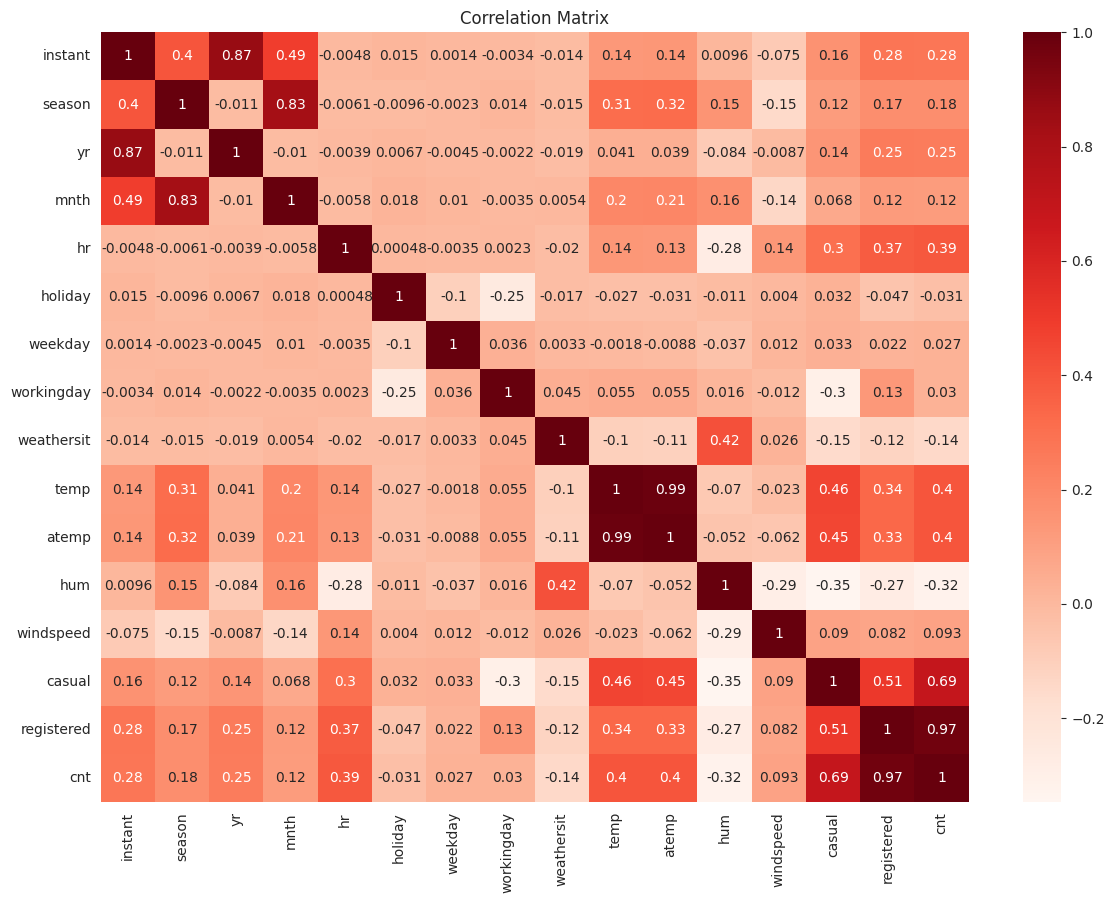

In [17]:
# heatmap showing correlation between features
plt.figure(figsize=(14, 10))  # fig size to avoid overlapping
sns.heatmap(
    df.select_dtypes(include='number').corr(),  # numerical columns
    cmap='Reds',  # colour scheme
    annot=True
)
plt.title('Correlation Matrix')
plt.show()

* The heatmap shows that `temp` and `atemp` are very strongly related, which makes sense because they are both temperature-based columns. 
* It also shows that `cnt` has stronger links with columns such as `temp`, `atemp`, `hr`, `casual` and `registered`.
* The columns `casual` and `registered` are very strongly related to `cnt` because `cnt` is made from these two columns. 
* This means they should not be used as input features when predicting `cnt`, otherwise the model would already have part of the answer.

---

### <u>Data Preparation<u>

In [ ]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [ ]:
"""
Drop columns that are not
useful for prediction
"""

df = df.drop(columns=[
    'instant',  # row index, not useful for prediction
    'dteday',  # date column, not useful for prediction
    'casual',  # casual + registered = cnt, keeping them would give the model the answer
    'registered'
])

# confirm changes
df.head()  # print the first 5 rows again with the new data after column dropping

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


---

### <u>Split Dataset<u>

In [20]:
"""
Split dataset into train,
validation and test sets
Lesson 8.1 used as guidance
"""

X_train, X_test, y_train, y_test = train_test_split(
                                    df.drop(['cnt'], axis=1), # drop target column to get features
                                    df['cnt'], # target variable to predict
                                    test_size=0.2, # 20% for testing
                                    random_state=0 # same split everytime
                                    )
print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:", X_test.shape, y_test.shape)

* Train set: (13903, 12) (13903,) 
* Test set: (3476, 12) (3476,)


In [ ]:
# split further into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
                                    X_train, # training features
                                    y_train, # training target
                                    test_size=0.2, # 20% of set used for validation
                                    random_state=0
                                    )

print("* Train set:", X_train.shape, y_train.shape)
print("* Validation set:", X_val.shape, y_val.shape)
print("* Test set:", X_test.shape, y_test.shape)

* Train set: (11122, 12) (11122,)
* Validation set: (2781, 12) (2781,)
* Test set: (3476, 12) (3476,)


---

### <u>Data Preprocessing Pipeline<u>

In [22]:
"""
Define data preprocessing pipeline
so you can scale features before model training
Lesson 8.1 used as guidance
"""

# define the function to create a preprocessing pipeline
def pipeline_pre_processing():  # define data preparation pipeline
    pipeline_base = Pipeline([

      ("feat_scaling", StandardScaler()) # scale features to have a mean 0 and a standard deviation 1 so they dont dominate each other

    ])
    return pipeline_base # return the pipeline so it can be used later

In [ ]:
# create the pipeline object
pipeline = pipeline_pre_processing()

# fit pipeline to train set and transform all sets
X_train = pipeline.fit_transform(X_train) # learn scaling from the train set and apply the knowledge so it doesnt cheat
X_val = pipeline.transform(X_val) # apply same scaling to validation set
X_test = pipeline.transform(X_test) # apply same scaling to test set

---

## Model Building

### <u>Model 1: Linear Regression<u>

In [24]:
"""
Build and train a Linear Regression
model to predict bike rental demand
Lesson 5.2 used as guidance
"""
# create a linear regression model
model_lr = LinearRegression()

# train the model on training set
model_lr.fit(X_train, y_train)

print("Linear Regression model trained successfully")

Linear Regression model trained successfully


In [25]:
# display coefficient (w) and intercept (b) in the format taught in lesson 5.2
print("w: ", model_lr.coef_[0])
print("b: ", model_lr.intercept_)

w:  22.89333463541776
b:  188.71120302103938


---

### <u>Model 2: Decision Tree Regressor<u>

In [26]:
"""
Build and train a Decision Tree
Regressor to predict bike rental demand
Lesson 6.1 used as guidance
"""
# define hyperparameters
max_depth = 5 # limits how deep the tree can grow
min_samples_split = 50 # how many samples needed to split a branch

# create decision tree regressor model
model_dt = DecisionTreeRegressor(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)

# train model on training set
model_dt.fit(X_train, y_train)

print("Decision Tree model trained successfully")

Decision Tree model trained successfully


---

### <u>Model Evaluation<u>

In [27]:
"""
Define helper functions to evaluate
model performance on different sets
Lesson 6.2 and 8.1 used as guidance
"""
# define function to evaluate model performance
def regression_performance(X_train, y_train, X_val, y_val, X_test, y_test, pipeline):
    """
    Print evaluation metrics for 
    train, validation and test sets
    """
    print("Model Evaluation \n")
    print("* Train Set")
    regression_evaluation(X_train, y_train, pipeline)
    print("* Validation Set")
    regression_evaluation(X_val, y_val, pipeline)
    print("* Test Set")
    regression_evaluation(X_test, y_test, pipeline)

# define function to calculate and display evaluation metrics
def regression_evaluation(X, y, pipeline):
    """
    Predicts using the model and calculates
    performance metrics comparing prediction to target
    """
    prediction = pipeline.predict(X) # makes predictions using the model
    print('R2 Score:', round(r2_score(y, prediction), 3)) # percentage of variance explained (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)
    print('Mean Absolute Error:', round(mean_absolute_error(y, prediction), 3))  # average error (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)
    print('Mean Squared Error:', round(mean_squared_error(y, prediction), 3))  # squared error (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)
    print('Root Mean Squared Error:', round(np.sqrt(mean_squared_error(y, prediction)), 3)) # error in same units as the bike count (https://www.statology.org/how-to-interpret-rmse/)
    print("\n")

In [28]:
# evaluate linear regression model
print("Linear Regression")
regression_performance(X_train, y_train, X_val, y_val, X_test, y_test, model_lr)

Linear Regression
Model Evaluation 

* Train Set
R2 Score: 0.387
Mean Absolute Error: 105.777
Mean Squared Error: 20058.751
Root Mean Squared Error: 141.629


* Validation Set
R2 Score: 0.377
Mean Absolute Error: 107.847
Mean Squared Error: 20577.276
Root Mean Squared Error: 143.448


* Test Set
R2 Score: 0.403
Mean Absolute Error: 104.379
Mean Squared Error: 19919.936
Root Mean Squared Error: 141.138




In [29]:
# evaluate decision tree model
print("Decision Tree Regressor")
regression_performance(X_train, y_train, X_val, y_val, X_test, y_test, model_dt)

Decision Tree Regressor
Model Evaluation 

* Train Set
R2 Score: 0.651
Mean Absolute Error: 70.471
Mean Squared Error: 11435.263
Root Mean Squared Error: 106.936


* Validation Set
R2 Score: 0.644
Mean Absolute Error: 72.507
Mean Squared Error: 11762.399
Root Mean Squared Error: 108.455


* Test Set
R2 Score: 0.645
Mean Absolute Error: 72.213
Mean Squared Error: 11847.217
Root Mean Squared Error: 108.845




---

### <u>Model Evaluation Plots<u>

In [30]:
"""
Plot model predictions against
actual values for all three sets
Lesson 6.2 and 8.1 used for guidance
"""
# function to plot actual vs predicted values for train, validation and test sets
def regression_evaluation_plots(X_train, y_train, X_val, y_val, X_test, y_test, pipeline, alpha_scatter=0.5):
    pred_train = pipeline.predict(X_train).reshape(-1) # predict on train set
    pred_val = pipeline.predict(X_val).reshape(-1) # predict on validation set
    pred_test = pipeline.predict(X_test).reshape(-1) # predict on test set
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6)) # create 3 side by side plots (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)

    sns.scatterplot(x=y_train, y=pred_train, alpha=alpha_scatter, ax=axes[0]) # plot train set (https://www.geeksforgeeks.org/python/scatterplot-using-seaborn-in-python/)
    sns.lineplot(x=y_train, y=y_train, color='red', ax=axes[0]) # plot perfect prediction line (https://seaborn.pydata.org/generated/seaborn.lineplot.html)
    axes[0].set_xlabel("Actual") # x axis label
    axes[0].set_ylabel("Predictions") # y axis label
    axes[0].set_title("Train Set") # plot title

    sns.scatterplot(x=y_val, y=pred_val, alpha=alpha_scatter, ax=axes[1]) # plot validation set
    sns.lineplot(x=y_val, y=y_val, color='red', ax=axes[1]) # plot perfect prediction line
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predictions")
    axes[1].set_title("Validation Set")

    sns.scatterplot(x=y_test, y=pred_test, alpha=alpha_scatter, ax=axes[2]) # plot test set
    sns.lineplot(x=y_test, y=y_test, color='red', ax=axes[2]) # plot perfect prediction line
    axes[2].set_xlabel("Actual")
    axes[2].set_ylabel("Predictions")
    axes[2].set_title("Test Set")

    plt.show() # display plots

Linear Regression


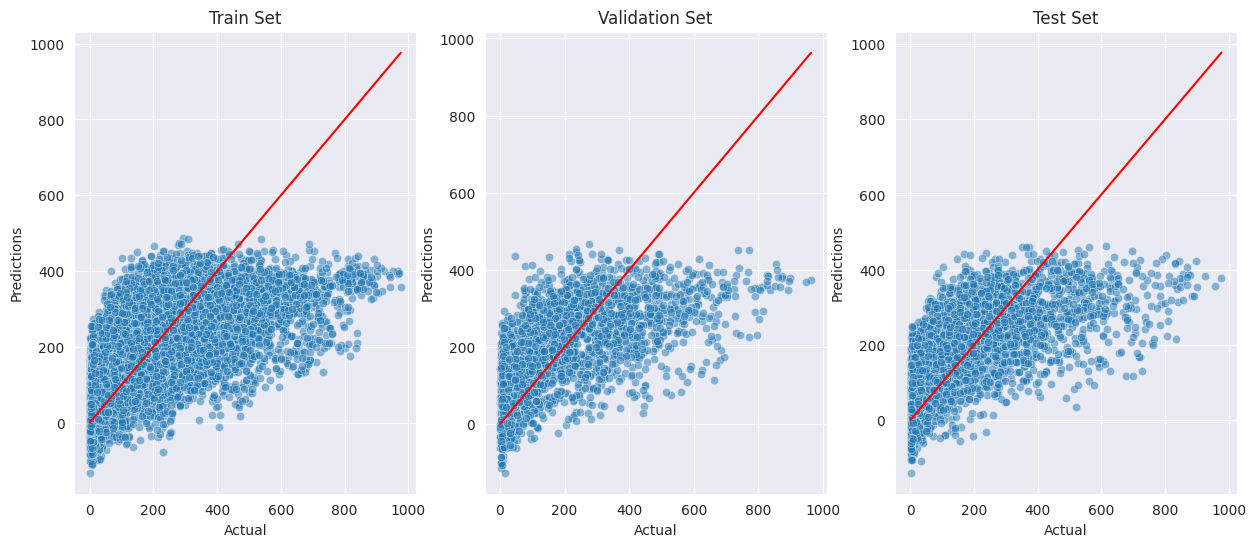

In [31]:
# plot evaluation for linear regression model
print("Linear Regression")
regression_evaluation_plots(X_train, y_train, X_val, y_val, X_test, y_test, model_lr)

Decision Tree Regressor


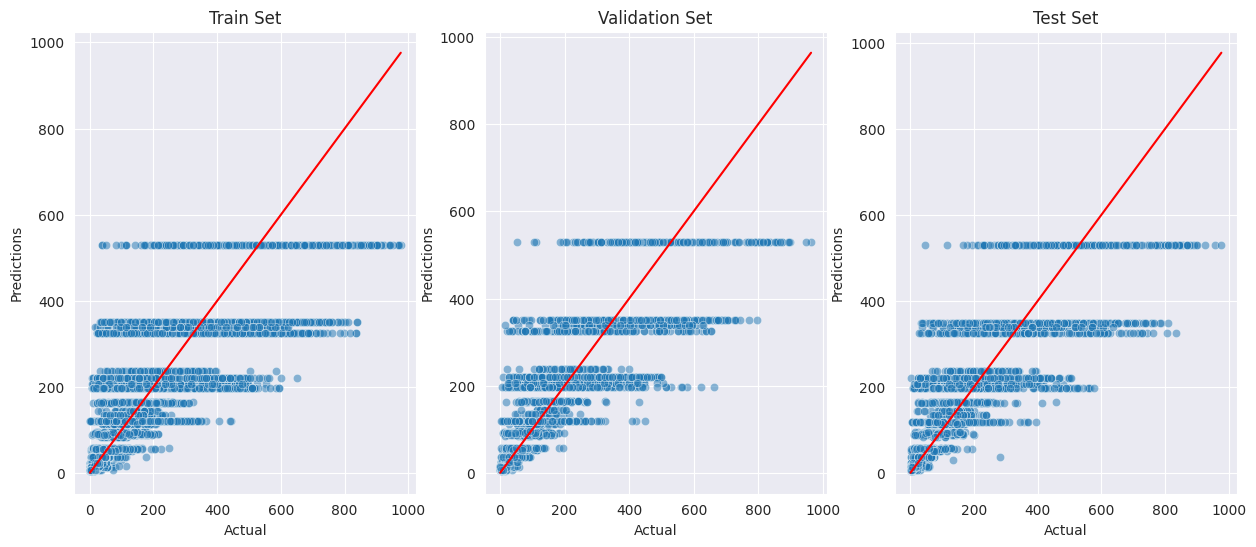

In [32]:
# plot evaluation for decision tree model
print("Decision Tree Regressor")
regression_evaluation_plots(X_train, y_train, X_val, y_val, X_test, y_test, model_dt)

---

### <u>Optimisation of Hyperparameters<u>

In [33]:
"""
Optimise max_depth hyperparameter
for Decision Tree Regressor
Lesson 6.1
"""

# function to return the train and validation errors for each max depth value
def max_depth_error(md):
    model = DecisionTreeRegressor(max_depth=md, random_state=42) # create model with given max depth
    model.fit(X_train, y_train) # train model
    train_error = 1 - model.score(X_train, y_train) # calculate train error
    val_error = 1 - model.score(X_val, y_val) # calculate validation error
    return {'Max Depth': md, 'Training Error': train_error, 'Validation Error': val_error} # return results

In [34]:
# loop through max depth values from 1 to 20
errors_list = []  # empty list to store results

for md in range(1, 21):
    result = max_depth_error(md) # get error for each max depth
    errors_list.append(result) # add to list

errors_df = pd.DataFrame(errors_list) # convert to dataframe
errors_df # display results

,Max Depth,Training Error,Validation Error
0,1,0.692786,0.701009
1,2,0.587769,0.579751
2,3,0.507871,0.501377
3,4,0.431220,0.420518
4,5,0.349442,0.356368
5,6,0.305208,0.305152
6,7,0.208075,0.207993
7,8,0.150699,0.174933
8,9,0.100903,0.132304
9,10,0.069375,0.121663


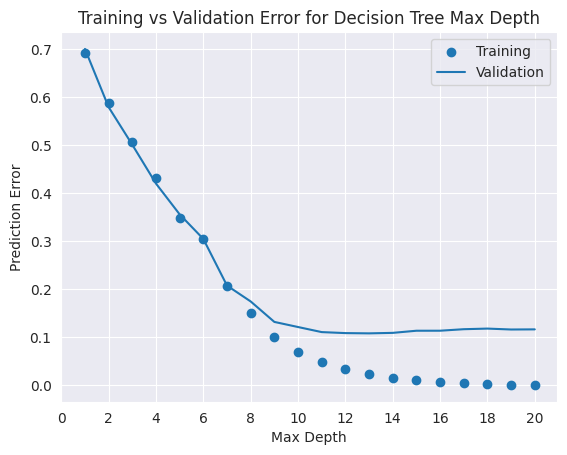

In [35]:
# plot training vs validation error for each max depth value
plt.figure()
plt.scatter(errors_df['Max Depth'], errors_df['Training Error']) # plot training error
plt.plot(errors_df['Max Depth'], errors_df['Validation Error']) # plot validation error
plt.title('Training vs Validation Error for Decision Tree Max Depth')
plt.xticks(range(0, 21, 2)) # x axis ticks
plt.xlabel('Max Depth')
plt.ylabel('Prediction Error')
plt.legend(['Training', 'Validation'])
plt.show() # display chart

In [36]:
best_depth = errors_df.loc[errors_df['Validation Error'].idxmin(), 'Max Depth']
print("Best max_depth:", best_depth)

Best max_depth: 13


---

### <u>Model Comparison<u>

In [37]:
"""
Compare both models using
evaluation metrics
"""
# compare both models on test set
print("Linear Regression")
regression_evaluation(X_test, y_test, model_lr)

print("Decision Tree Regressor")
regression_evaluation(X_test, y_test, model_dt)

Linear Regression
R2 Score: 0.403
Mean Absolute Error: 104.379
Mean Squared Error: 19919.936
Root Mean Squared Error: 141.138


Decision Tree Regressor
R2 Score: 0.645
Mean Absolute Error: 72.213
Mean Squared Error: 11847.217
Root Mean Squared Error: 108.845




### <u>Verdict<u>

* Based on the evaluation metrics on the test set, the Decision Tree Regressor outperforms Linear Regression across all metrics.

* It achieved a higher R2 score of 0.645 compared to 0.403, and lower error metrics across MAE, MSE and RMSE. 

* Therefore the Decision Tree Regressor is selected as the best performing model.

* (https://www.bmc.com/blogs/mean-squared-error-r2-and-variance-in-regression-analysis/)

* (https://www.datacamp.com/tutorial/mean-absolute-error)

* (https://www.datacamp.com/tutorial/rmse)

---

### <u>Save Models<u>

In [38]:
"""
Save trained models to models folder
Lesson 5.1 code adapted
"""
# save linear regression model
joblib.dump(model_lr, '../models/linear_regression.pkl') # save model to models folder (https://joblib.readthedocs.io/en/latest/generated/joblib.dump.html)
print("Linear Regression model saved successfully")

Linear Regression model saved successfully


In [39]:
# save decision tree model
joblib.dump(model_dt, '../models/decision_tree.pkl')
print("Decision Tree model saved successfully")

Decision Tree model saved successfully


In [49]:
# save preprocessing pipeline
joblib.dump(pipeline, '../models/preprocessing_pipeline.pkl')
print("Preprocessing pipeline saved successfully")

Preprocessing pipeline saved successfully


---

## Prediction

### <u>Test Set<u>

In [40]:
"""
Test the best model
on the test set
Lesson 8.1 used for guidance
"""
# predict on test set using best model (which is the decision tree)
pred_test = model_dt.predict(X_test) # make predictions on unseen test data
pred_test

array([ 14.44907407,   6.45877378, 325.59489633, ...,  36.78193146,
        13.3       , 325.59489633], shape=(3476,))

In [41]:
# this will print first 10 actual vs the predicted values
print("Actual vs Predicted:")
for i in range(10):
    print(f"Actual: {y_test.iloc[i]} | Predicted: {round(pred_test[i], 1)}")

Actual vs Predicted:
Actual: 7 | Predicted: 14.4
Actual: 5 | Predicted: 6.5
Actual: 743 | Predicted: 325.6
Actual: 208 | Predicted: 198.5
Actual: 333 | Predicted: 238.0
Actual: 187 | Predicted: 120.0
Actual: 124 | Predicted: 325.6
Actual: 925 | Predicted: 529.2
Actual: 212 | Predicted: 349.9
Actual: 161 | Predicted: 120.0


### Test Set Prediction Results

* The model shows reasonable performance on lower bike rental counts, for example predicting 6.5 against an actual of 5.

* However the model struggles with higher rental counts, for example predicting 325.6 against an actual of 743.

* This is can be seen in the R2 score of 0.645 on the test set, so the model only explains 64.5% of the variance in bike rental demand.

* The remaining 35.5% may be due to factors not captured in the dataset.

* The model could be improved with more hyperparameter optimisation.

### <u>Individual Input<u>

In [42]:
"""
Predict bike rental demand
for a single input
Lesson 5.1 and 5.2 used for guidance
"""
# create a single input sample
bike_input = {
    'season': [1],       # winter
    'yr': [1],           # year 2
    'mnth': [1],         # january
    'hr': [8],           # 8am
    'holiday': [0],      # not a holiday
    'weekday': [1],      # monday
    'workingday': [1],   # working day
    'weathersit': [1],   # clear weather
    'temp': [0.24],      # temperature
    'atemp': [0.2879],   # feels like temperature
    'hum': [0.81],       # humidity
    'windspeed': [0.0]   # windspeed
}

# convert dictionary to dataframe
sample = pd.DataFrame(bike_input)
sample # display sample

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,1,1,8,0,1,1,1,0.24,0.2879,0.81,0.0


In [43]:
"""
Scale sample and predict
bike rental demand 
Lesson 6.2 used for guidance
"""
# scale sample using same pipeline used on training data
sample_scaled = pipeline.transform(sample) # scale the sample

# predict bike rentals for sample
prediction = model_dt.predict(sample_scaled) # predict using decision tree model
print(f"Predicted bike rentals: {round(prediction[0], 0)}")

Predicted bike rentals: 198.0


---

## Hyperparameter Optimisation - Model Improvement

### <u>Analysis<u>

* After analysing the Training vs Validation Error plot again, the validation error is at its lowest at a max_depth of 13. 

* After this point the validation error starts to rise slightly which is a sign of overfitting. (Lesson 6.1)

* The original model was built with a max_depth of 5 which was too shallow. 

* The model is now rebuilt below with max_depth of 13 to improve performance.

In [44]:
"""
Rebuild Decision Tree model with
optimised hyperparameters based on
the hyperparameter graph
Lesson 6.1 used for guidance
"""
# update max depth based on hyperparameter optimisation plot
max_depth = best_depth # lowest validation error found at max depth 13

# rebuild model with optimised hyperparameters
model_dt_v2 = DecisionTreeRegressor(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)

# train model on training set
model_dt_v2.fit(X_train, y_train)

print("Optimised Decision Tree model trained successfully")

Optimised Decision Tree model trained successfully


In [45]:
# evaluate optimised decision tree model
print("Optimised Decision Tree Regressor")
regression_performance(X_train, y_train, X_val, y_val, X_test, y_test, model_dt_v2)

Optimised Decision Tree Regressor
Model Evaluation 

* Train Set
R2 Score: 0.93
Mean Absolute Error: 29.501
Mean Squared Error: 2274.898
Root Mean Squared Error: 47.696


* Validation Set
R2 Score: 0.892
Mean Absolute Error: 35.141
Mean Squared Error: 3565.352
Root Mean Squared Error: 59.711


* Test Set
R2 Score: 0.902
Mean Absolute Error: 34.852
Mean Squared Error: 3281.879
Root Mean Squared Error: 57.288




In [46]:
# predict on test set using optimised model
pred_test_v2 = model_dt_v2.predict(X_test) # make predictions on unseen test data

# display first 10 actual vs predicted values
print("Actual vs Predicted (Optimised Model):")
for i in range(10):
    print(f"Actual: {y_test.iloc[i]} | Predicted: {round(pred_test_v2[i], 1)}")

Actual vs Predicted (Optimised Model):
Actual: 7 | Predicted: 7.5
Actual: 5 | Predicted: 4.5
Actual: 743 | Predicted: 375.3
Actual: 208 | Predicted: 205.1
Actual: 333 | Predicted: 291.2
Actual: 187 | Predicted: 201.2
Actual: 124 | Predicted: 127.6
Actual: 925 | Predicted: 871.7
Actual: 212 | Predicted: 199.3
Actual: 161 | Predicted: 114.7


In [47]:
# scale sample and predict using optimised model
sample_scaled = pipeline.transform(sample) # scale sample
prediction_v2 = model_dt_v2.predict(sample_scaled) # predict using optimised model
print(f"Predicted bike rentals: {round(prediction_v2[0], 0)}")

Predicted bike rentals: 407.0


### Overall 

* The optimised model with max_depth of 13 shows clear improvement over the original model with max_depth of 5. 
* Predictions are considerably closer to actual values across the test set. 
* The individual input prediction of 407 bikes at 8am on a Monday morning working day also seems reasonable because of commuter rush hour context.

---

### <u>Save Optimised Model<u>

In [48]:
# save optimised decision tree model
joblib.dump(model_dt_v2, '../models/optimised_decision_tree.pkl')
print("Optimised Decision Tree model saved successfully")

Optimised Decision Tree model saved successfully


---

### <u>Final Comparison Table<u>

In [51]:
# calculate test predictions for each model
pred_test_lr = model_lr.predict(X_test)
pred_test_dt = model_dt.predict(X_test)
pred_test_dt_v2 = model_dt_v2.predict(X_test)

# calculate R2 scores
r2_lr = r2_score(y_test, pred_test_lr)
r2_dt = r2_score(y_test, pred_test_dt)
r2_dt_v2 = r2_score(y_test, pred_test_dt_v2)

# calculate RMSE values
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_test_lr))
rmse_dt = np.sqrt(mean_squared_error(y_test, pred_test_dt))
rmse_dt_v2 = np.sqrt(mean_squared_error(y_test, pred_test_dt_v2))

# create final model comparison table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Optimised Decision Tree'],
    'Test R2': [r2_lr, r2_dt, r2_dt_v2],
    'Test RMSE': [rmse_lr, rmse_dt, rmse_dt_v2]
})

comparison_df

,Model,Test R2,Test RMSE
0,Linear Regression,0.403043,141.138003
1,Decision Tree,0.644965,108.844920
2,Optimised Decision Tree,0.901649,57.287688


* With an R2, the best possible score is 1.0, so the optimised dt performed the best

* With an RMSE, the best is the lowest score, so again the optimised dt performed the best

---

## References

* (https://www.kaggle.com/docs/api)

* (https://plotly.com/python-api-reference/generated/plotly.express.scatter)

* (https://plotly.com/python-api-reference/generated/plotly.express.histogram.html)

* (https://seaborn.pydata.org/generated/seaborn.heatmap.html)

* (https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)

* (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

* (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)

* (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)

* (https://www.statology.org/how-to-interpret-rmse/)

* (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)

* (https://www.geeksforgeeks.org/python/scatterplot-using-seaborn-in-python/)

* (https://seaborn.pydata.org/generated/seaborn.lineplot.html)

* (https://seaborn.pydata.org/generated/seaborn.lineplot.html)

* (https://www.bmc.com/blogs/mean-squared-error-r2-and-variance-in-regression-analysis/)

* (https://www.datacamp.com/tutorial/mean-absolute-error)

* (https://www.datacamp.com/tutorial/rmse)

* (https://joblib.readthedocs.io/en/latest/generated/joblib.dump.html)

* (https://github.com/kathrinmzl/MalariaDetector/tree/main)

---

I have also conducted my 
* `git status`
* `git add --all`
* `git commit -m "commit message"`
* `git push`

---

Sadia Maio SM